## <b><u>Infrared.city-1</u>: Tree detection</b>
### <b>Introduction</b>

As urban areas are expanding and global temperatures rise due to climate change, being able to understand how trees can help cool cities has become increasingly important. Furthermore, trees reduce the risk of flooding in cities and promote health and wellbeing. Our project aims at taking the first step in the direction of better tree coverage in urban areas by creating a model which is able to predict tree locations using satellite imagery of densely populated areas.
<br>

### <b>Notebook structure</b>

&nbsp;&nbsp;&nbsp;<b>1. Fetching & preparing the data</b><br>
&nbsp;&nbsp;&nbsp;<b>2. Exploratory data analysis</b><br>
&nbsp;&nbsp;&nbsp;<b>3. Training & testing the model</b><br>
&nbsp;&nbsp;&nbsp;<b>4. Exporting to database format</b><br>

### <b>Shared folder structure</b>
/home/jovyan/ideas-dslab-group1-shared/<br>
├── <b>raw_data/</b> (backup)<br>
│&ensp;&ensp;&ensp;      ├── baumkataster data/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── vienna_baumkataster<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── paris_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── prag_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   └── hamburger_baumkataster/<br>
│&ensp;&ensp;&ensp;   ├── sentinel data/<br>
│&ensp;&ensp;&ensp;   └── osm data/<br>
└── <b>cleaned_data/</b><br>
<br>

## <b>1. Fetching & preparing the data</b>

### Scraping the data

For our project we use following <a href="https://opentrees.org/#pos=3.7/52.76/0.38">publicly available data</a>:

1. <b><a href="https://www.data.gv.at/datasets/c91a4635-8b7d-43fe-9b27-d95dec8392a7?locale=en">Vienna Baumkataster</a></b> <i>Official City of Vienna tree cadastre with tree locations (GeoJSON)</i><br>

2. <b><a href="https://opendata.paris.fr/explore/dataset/les-arbres/export/?disjunctive.espece&disjunctive.typeemplacement&disjunctive.arrondissement&disjunctive.genre&disjunctive.libellefrancais&disjunctive.varieteoucultivar&disjunctive.stadedeveloppement&disjunctive.remarquable">Paris Le Arbres</a></b> <i>Official City of Paris tree cadastre with tree locations (GeoJSON)</i><br>

3. <b><a href="https://opendata-ajuntament.barcelona.cat/data/en/dataset/arbrat-viari">Barcelona</a></b> <i>Official City of Barcelona tree cadastre with tree locations (JSON)</i><br>

4. <b><a href="https://metaver.de/trefferanzeige?docuuid=C1C61928-C602-4E37-AF31-2D23901E2540">Hamburg Strassenbaumkataster</a></b> <i>Official City of Hambuger tree cadastre with tree locations (GeoJSON)</i><br>

5. <b><a href="https://dataspace.copernicus.eu/data-collections/copernicus-sentinel-missions/sentinel-2">Sentinel-2 Satellite Images</a></b> <i>Multispectral satellite imagery including 10 m resolution bands (GeoTIFF)</i><br>


6. <b><a href="https://download.geofabrik.de/europe">OpenStreetMap Urban Features</a></b> <i>OpenStreetMap vector data, including urban context such as buildings and roads ((GeoJSON/shapefile)</i><br>


<b>Idea:</b><br>
<b>Paris → western / oceanic</b><br>
<b>Hamburg → northern / maritime</b><br>
<b>Vienna → continental</b><br>
<b>Barcelona → warm / Mediterranean</b><br>

We have approx. 154gb free space:<br>

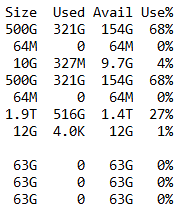<br>

And 117gb ram:<br>
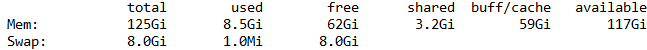:<br>

<b>With that, we can now fetch our datasets accordingly:

## Continental: Vienna Baumkataster

In [1]:
#1.getting buamkataster
#Lizenz: https://creativecommons.org/licenses/by/4.0/deed.de
#BEZIRK: Wiener Gemeindebezirk, in dem der Baum steht; OBJEKT_STRASSE: Anlage, Objekt oder Straße, in der der Baum steht; BAUMNUMMER: Nummer des Baumes; GEBIETSGRUPPE: Gebiet, in dem der Baum steht; GATTUNG_ART: Information, um welche Baumart es sich handelt; PFLANZJAHR: das Jahr, in dem der Baum gepflanzt wurde; PFLANZJAHR_TXT: Werte aus PFLANZJAHR in Textformat, Nullwerte werden in Text "nicht bekannt" umgewandelt; STAMMUMFANG: Umfang des Baumstammes in cm in einem Meter Höhe; STAMMUMFANG_TXT: Werte aus STAMMUMFANG in Textformat mit Zusatz " cm", Nullwerte werden in Text "nicht bekannt" umgewandelt; BAUMHOEHE: Einteilung in 8 Größenkategorien der Baumhöhe + Nullwert; BAUMHOEHE_TXT: Größenkategorien der Baumhöhe in Textformat direkt aus Quelldatenbank, Leereinträge werden in Text "nicht bekannt" umgewandelt; KRONENDURCHMESSER: Einteilung in 8 Größenkategorien des Baumkronendurchmessers + Nullwert; KRONENDURCHMESSER_TXT: Größenkategorien der Kronendurchmesser in Textformat direkt aus Quelldatenbank, Leereinträge werden in Text "nicht bekannt" umgewandelt;
#path to shared folder: /home/jovyan/ideas-dslab-group1-shared
import requests

r = requests.get("https://data.wien.gv.at/daten/geo?service=WFS&version=1.1.0&request=GetFeature&typeName=ogdwien:BAUMKATOGD&outputFormat=json&srsName=EPSG:4326")
open("/home/jovyan/ideas-dslab-group1-shared/baumkataster data/vienna_baumkataster.geojson", "wb").write(r.content)

137309796

In [3]:
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 194.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 153.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 204.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]


In [3]:
import geopandas as gpd

baumkataster = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/vienna_baumkataster.geojson")
print(baumkataster.head())
print(len(baumkataster))

                     id   OBJECTID  BAUM_ID DATENFUEHRUNG  BEZIRK  \
0  BAUMKATOGD.780540084  780540084   344016     magistrat     2.0   
1  BAUMKATOGD.780540085  780540085   282486     magistrat     2.0   
2  BAUMKATOGD.780540086  780540086   157598     magistrat    22.0   
3  BAUMKATOGD.780540087  780540087   282483     magistrat     2.0   
4  BAUMKATOGD.780540088  780540088   282481     magistrat     2.0   

                 OBJEKT_STRASSE          GEBIETSGRUPPE  \
0  02., Prater - Pelzmais, MA42     MA 42 - Parkanlage   
1  02., Prater - Pelzmais, MA42     MA 42 - Parkanlage   
2               Wagramer Straße  Hauptstraße B8/B3b/S2   
3  02., Prater - Pelzmais, MA42     MA 42 - Parkanlage   
4  02., Prater - Pelzmais, MA42     MA 42 - Parkanlage   

                             GATTUNG_ART  PFLANZJAHR PFLANZJAHR_TXT  \
0        Juglans nigra (Schwarznussbaum)        2020           2020   
1    Robinia pseudoacacia (Scheinakazie)        1918           1918   
2          Acer platano

## Western/oceanic: Paris Baumkataster


In [6]:
import geopandas as gpd

baumkataster = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/paris_baumkataster.geojson")
print(baumkataster.head())
print(len(baumkataster))

   idbase typeemplacement domanialite   arrondissement complementadresse  \
0  128501           Arbre      Jardin  PARIS 15E ARRDT      POURTOUR N°1   
1  133675           Arbre      Jardin  PARIS 15E ARRDT               NaN   
2  207811           Arbre  Alignement   PARIS 7E ARRDT                65   
3  219024           Arbre  Alignement   PARIS 7E ARRDT                47   
4  233043           Arbre  Alignement  PARIS 15E ARRDT            38 bis   

                                          adresse idemplacement  \
0  SQUARE DU CLOS FEUQUIERES / 30 RUE DESNOUETTES     000101028   
1  SQUARE CARLO SARRABEZOLLES / 1 RUE RENE RAVAUD     000101049   
2                                    QUAI D ORSAY     000301036   
3                                 AVENUE DUQUESNE     000903005   
4                                      RUE BALARD     000602018   

  libellefrancais          genre         espece varieteoucultivar  \
0         Tilleul          Tilia      americana               NaN   
1 

## Warm/mediterranean: Barcelona

In [11]:
import pandas as pd

df = pd.read_json("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/barcelona_baumkataster.json")
print(df.head())
print(df.columns)

        codi    x_etrs89     y_etrs89    latitud  longitud tipus_element  \
0  0000377AR  430700.647  4587547.432  41.436508  2.170511  PALMERA ZONA   
1  0000386AR  430035.239  4587693.836  41.437769  2.162530    ARBRE ZONA   
2  0000387AR  430032.831  4587696.005  41.437788  2.162501    ARBRE ZONA   
3  0000388AR  430030.367  4587698.393  41.437810  2.162471    ARBRE ZONA   
4  0000389AR  430581.230  4587409.021  41.435251  2.169097    ARBRE ZONA   

                    espai_verd                     adreca  cat_especie_id  \
0  Central de Nou Barris, Parc  Pl Major de Nou Barris, 0              48   
1  Central de Nou Barris, Parc    C\ Doctor Letamendi, 90             126   
2  Central de Nou Barris, Parc    C\ Doctor Letamendi, 90             126   
3  Central de Nou Barris, Parc    C\ Doctor Letamendi, 90             126   
4  Central de Nou Barris, Parc             C\ Borgonya, 2              99   

       cat_nom_cientific  ... categoria_arbrat data_plantacio tipus_aigua  \
0  

## Northern/maritime: Hamburg Straßenbaumkataster

EPSG:25832 == metric with meters, prefered for our ML-model for calculations<br>
hpa = all trees without Hamburger Hafen (so we need both datasets)<br>
Obtained via manual download:

In [5]:
baumkataster_hamburg_hpa = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/hamburg_baumkataster/de_hh_up_strassenbaumkataster_EPSG_25832.json")
baumkataster_hamburg = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/hamburg_baumkataster/de_hh_up_strassenbaumkataster_hpa_EPSG_25832.json")
print(baumkataster_hamburg_hpa.head())
print(baumkataster_hamburg.head())

                                id     baumid  baumnummer           gattung  \
0  DE.HH.UP_STRASSENBAUMKATASTER_1  100000117   F122-83-1  Populus / Pappel   
1  DE.HH.UP_STRASSENBAUMKATASTER_2  100000118  F122-134-1  Populus / Pappel   
2  DE.HH.UP_STRASSENBAUMKATASTER_3  100000119   F122-67-1  Populus / Pappel   
3  DE.HH.UP_STRASSENBAUMKATASTER_4  100000120   F122-88-1  Populus / Pappel   
4  DE.HH.UP_STRASSENBAUMKATASTER_5  100000121  F122-171-1  Populus / Pappel   

  gattung_latein gattung_deutsch                                     art  \
0        Populus          Pappel  Populus canadensis / Kanadische Pappel   
1        Populus          Pappel  Populus canadensis / Kanadische Pappel   
2        Populus          Pappel  Populus canadensis / Kanadische Pappel   
3        Populus          Pappel  Populus canadensis / Kanadische Pappel   
4        Populus          Pappel  Populus canadensis / Kanadische Pappel   

           art_latein        art_deutsch  \
0  Populus canadensis  K

## Sentinel-2 Satellite Images

In [ ]:
#2.getting sential-2 satellite images


## OpenStreetMap Urban Features

In [ ]:
#3.getting openStreetMap urban features



### Cleaning the data

<b>We will now prepare our datasets:</b>

## Idea for database, we take satellite img of Prag and add this to our database:


<u>cell_id:</u> id of 10m×10m cell of the satellite images (e.g. idk)<br>
<u>city=Prag</u><br>
<u>lat_center</u>   
<u>lon_center</u>  
<u>tree_count:</u> number of trees in that cell <br>
<u>has_palm</u>   
<u>has_pine</u>   
<u>has_leaf</u>     
<u>has_road</u><br>
has_building</u><br>
<u>is_park</u><br>